## EDA on Imdb_top_5000_tv Shows

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('imdb_top_5000_tv_shows.csv')
df

,tconst,primaryTitle,startYear,endYear,rank,averageRating,numVotes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0903747,Breaking Bad,2008,2013.0,1,9.5,2312017,"Michelle MacLaren, Adam Bernstein, Vince Gilli...","Vince Gilligan, Peter Gould, George Mastras, S...","Crime, Drama, Thriller","<a href=""https://www.imdb.com/title/tt0903747""...","<a href=""https://www.imdb.com/title/tt0903747""..."
1,tt0185906,Band of Brothers,2001,2001.0,2,9.4,559065,"David Frankel, Mikael Salomon, Tom Hanks, Davi...","Stephen Ambrose, Erik Bork, E. Max Frye, Tom H...","Action, Drama, History","<a href=""https://www.imdb.com/title/tt0185906""...","<a href=""https://www.imdb.com/title/tt0185906""..."
2,tt7366338,Chernobyl,2019,2019.0,3,9.3,942083,Johan Renck,Craig Mazin,"Drama, History, Thriller","<a href=""https://www.imdb.com/title/tt7366338""...","<a href=""https://www.imdb.com/title/tt7366338""..."
3,tt0795176,Planet Earth,2006,2006.0,4,9.4,226878,"Alastair Fothergill, Mark Linfield","David Attenborough, Vanessa Berlowitz, Alastai...","Documentary, Family","<a href=""https://www.imdb.com/title/tt0795176""...","<a href=""https://www.imdb.com/title/tt0795176""..."
4,tt5491994,Planet Earth II,2016,2016.0,5,9.4,165947,"Justin Anderson, Ed Charles, Fredi Devas, Chad...",Elizabeth White,Documentary,"<a href=""https://www.imdb.com/title/tt5491994""...","<a href=""https://www.imdb.com/title/tt5491994""..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,tt2882382,Gerçek Kesit,1993,2006.0,4996,7.9,778,-,-,"Action, Crime, Fantasy","<a href=""https://www.imdb.com/title/tt2882382""...","<a href=""https://www.imdb.com/title/tt2882382""..."
4996,tt9165752,Songland,2019,2020.0,4997,8.1,776,Ivan Dudynsky,-,Reality-TV,"<a href=""https://www.imdb.com/title/tt9165752""...","<a href=""https://www.imdb.com/title/tt9165752""..."
4997,tt0165019,The Visitors,1983,NaN,4998,8.2,774,Jindrich Polák,"Ota Hofman, Jindrich Polák","Comedy, Family, Fantasy","<a href=""https://www.imdb.com/title/tt0165019""...","<a href=""https://www.imdb.com/title/tt0165019""..."
4998,tt0456788,Karanlikta Kosanlar,2001,2001.0,4999,8.5,773,Ugur Yücel,"Defne Kayalar, Ugur Yücel, Ahmet Ümit","Crime, Drama, Mystery","<a href=""https://www.imdb.com/title/tt0456788""...","<a href=""https://www.imdb.com/title/tt0456788""..."


#### Finding Shape of the data set which means how many row and column are there 

In [3]:
print("Row : ",df.shape[0])
print("Columns : ",df.shape[1])

Row :  5000
Columns :  12


#### Here i check types of column for knowing which column contain numerical or categorical contex  and check basic informations

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           5000 non-null   object 
 1   primaryTitle     5000 non-null   object 
 2   startYear        5000 non-null   int64  
 3   endYear          4115 non-null   float64
 4   rank             5000 non-null   int64  
 5   averageRating    5000 non-null   float64
 6   numVotes         5000 non-null   int64  
 7   directors        5000 non-null   object 
 8   writers          5000 non-null   object 
 9   genres           5000 non-null   object 
 10  IMDbLink         5000 non-null   object 
 11  Title_IMDb_Link  5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


#### Now i check missing values in Data 

In [5]:
df.isna().sum()
# so only 'endYear' column only contain null values it is : 885  

tconst               0
primaryTitle         0
startYear            0
endYear            885
rank                 0
averageRating        0
numVotes             0
directors            0
writers              0
genres               0
IMDbLink             0
Title_IMDb_Link      0
dtype: int64

i am filling 'Ongoing' String at null value because it make sense because if i am filling the same year 
that not might meaning full because it means the show in ended but that is also wrong step 
this is IMBA rating data so it's less chances to contain null value is has some sense for
contain null value so that's why i fill 'Ongaing' string instead of putting any other things 

In [6]:
df['endYear'] = df['endYear'].fillna('Ongoing')

Now our data is totally clean it not contain any kind of null value 

In [7]:
df.isna().sum()

tconst             0
primaryTitle       0
startYear          0
endYear            0
rank               0
averageRating      0
numVotes           0
directors          0
writers            0
genres             0
IMDbLink           0
Title_IMDb_Link    0
dtype: int64

### Split into numerical and categorical portion 

In [8]:
df.dtypes

tconst              object
primaryTitle        object
startYear            int64
endYear             object
rank                 int64
averageRating      float64
numVotes             int64
directors           object
writers             object
genres              object
IMDbLink            object
Title_IMDb_Link     object
dtype: object

In [9]:
num_cols = df.select_dtypes(['int64','float64'])
cat_cols = df.select_dtypes(['object'])

#### Now we see the Statistical summary 

Here you can see the new import is 'TABULATE' typically tabulate is convert out data into design row and column way that means here i need statistical summary but if i directly write as 'df.describe' so it will give me normal format not a specific table format so that's why i call tablulate for table formating   

In [10]:
from tabulate import tabulate as tb

print("Only numerical columns :")
print(tb(df.describe(include='object'),headers='keys',tablefmt='grid'))
print("Include objects also ")
df.describe()

Only numerical columns :
+--------+-----------+----------------+-----------+-------------+-----------+----------+------------------------------------------------------------------------------+---------------------------------------------------------------------------------+
|        | tconst    | primaryTitle   | endYear   | directors   | writers   | genres   | IMDbLink                                                                     | Title_IMDb_Link                                                                 |
+========+===========+================+===========+=============+===========+==========+==============================================================================+=================================================================================+
| count  | 5000      | 5000           | 5000      | 5000        | 5000      | 5000     | 5000                                                                         | 5000                                                     

,startYear,rank,averageRating,numVotes
count,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2008.901800,2500.500000,8.004300,2.713506e+04
std,14.376087,1443.520003,0.438322,9.023652e+04
min,1948.000000,1.000000,7.300000,7.110000e+02
25%,2003.000000,1250.750000,7.700000,2.095500e+03
50%,2014.000000,2500.500000,8.000000,5.185000e+03
75%,2019.000000,3750.250000,8.300000,1.701000e+04
max,2025.000000,5000.000000,9.600000,2.420347e+06


In [11]:
num_cols.columns
cat_cols.columns

Index(['tconst', 'primaryTitle', 'endYear', 'directors', 'writers', 'genres',
       'IMDbLink', 'Title_IMDb_Link'],
      dtype='object')

Find out maximum and minimum num of votes with their primary title name

In [12]:
max_rating = df['numVotes'].max()

top_rated = df[df['numVotes'] == max_rating][['primaryTitle','numVotes']]
top_rated

,primaryTitle,numVotes
5,Game of Thrones,2420347


In [13]:
min_rating= df['numVotes'].min()

min_rated = df[df['numVotes'] == min_rating][['primaryTitle','numVotes']]
min_rated

,primaryTitle,numVotes
3059,Raja Shivchhatrapati,711


Average : Number of votes

In [14]:
avgofvotes = num_cols['numVotes'].mean()
avgofvotes

27135.0648

Here we fin out the outliers of our dataset in contex of Number of voting and as well as here we can see i use seaborn's boxenplot for easy to undertand and visulize the things 

<Axes: xlabel='startYear'>

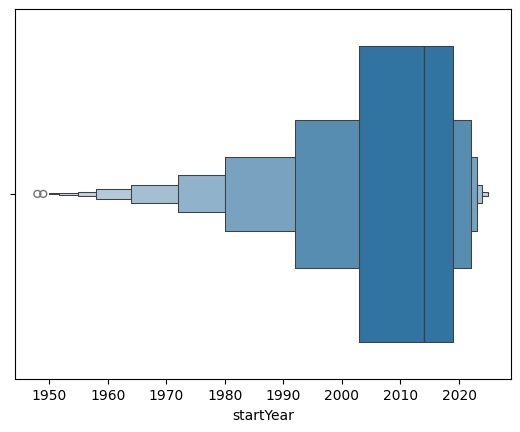

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxenplot(x=df['startYear'])

### Univariate analysis
#### Distribution of Numerical Column by visualizing

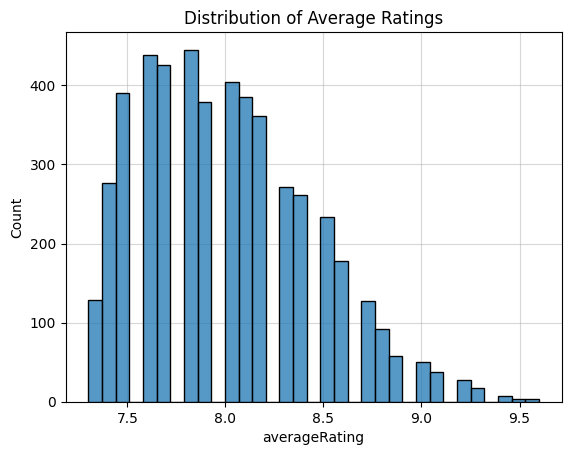

In [16]:
sns.histplot(num_cols['averageRating'],zorder = 10)
plt.title('Distribution of Average Ratings')
plt.grid(alpha = .5)
plt.show()

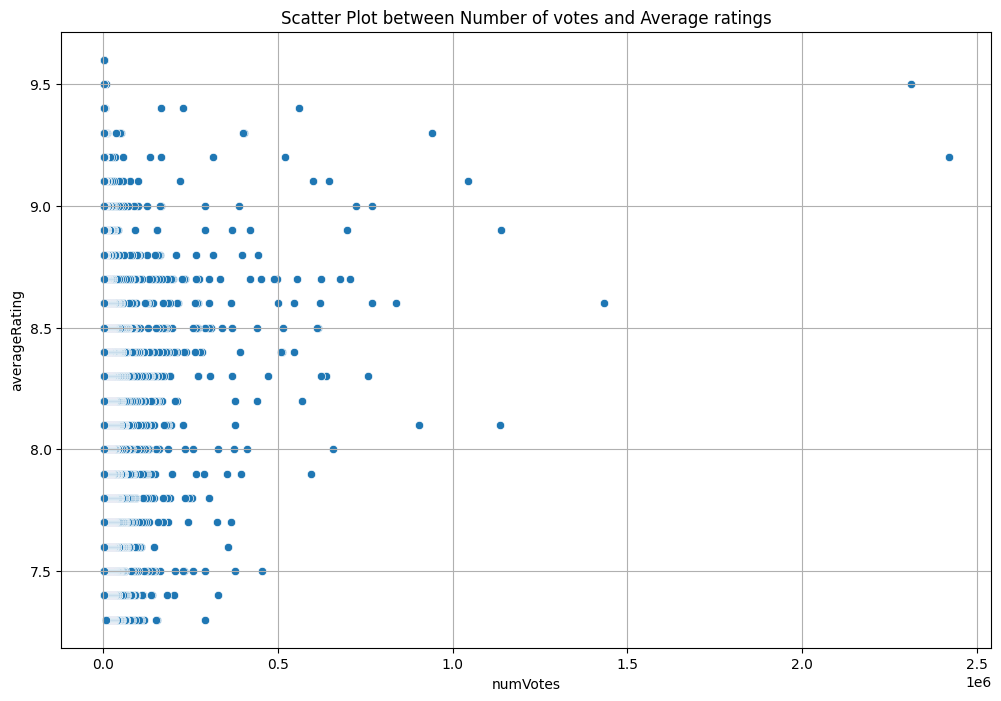

In [17]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=num_cols['numVotes'], y = num_cols['averageRating'])
plt.title('Scatter Plot between Number of votes and Average ratings')
plt.grid()
plt.show()

Text(0.5, 1.0, 'Matrix Correlation')

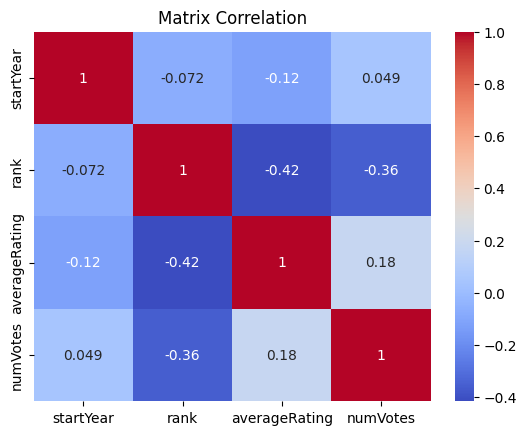

In [18]:
correlation_matrix = num_cols.corr()
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.title('Matrix Correlation')

--- 

## Insights 

### About dataset  

Here this IMDB dataset shows to us each unique number of each tv_shows with their start year, end year, rank, average ratings, number of votes, list of directors names, writers, genres which mean type of show and also this dataset provide clickable link so we arrived those particular tv show page  

this is all about dataset 

### Understanding major aspect by visualizing the things 

#### Boxen plot :
Using boxenplot we find the most of starting years of movies as we seen that around 2001 to 2020 duration. overview of how many movies are started and also we see that little bits of outliers 

#### Histplot : 
I analyze based on single column which is known as univariate analysis 
By using this histplot we show that mostly people given ratings between 7.5 to 8.0 and 9 to 9.5 are too low ratings 

#### Scatterplot : 
Basically this scatter plot is shows the average ratings basis of number of Votes so, here we see around 2.5 number of votes have 9 or 9.5 ratings and also we see most of ratings are in between 0 to 0.5 number of votes  

#### Matrix correlation 
Typically this matrix correlation is represent the relation between the all numeric columns, for example here we see at vertical side start year and horizontal side at startyear same column obviously this both relate nicely and then we see and startyear and rank so there negative number so that means that range of correlation we have between rank and startYear so just like that we understand the relationship between each numerical column 


### Summary 
Overall here i gain information of TV_shows by visualize i understand which years did the movies become and their outliers, i also understand people interest in movies by seen the avgratings and knowing the average ratings base on voting and then lastly find the correlation of numerical features using matrix heatmap